# Veterinary Clinic Network Analytics

Este proyecto presenta un análisis completo de datos operativos
de una red simulada de clínicas veterinarias.

El objetivo principal es comprender los patrones de demanda de
servicios veterinarios y desarrollar modelos predictivos capaces
de anticipar el número de visitas diarias en cada clínica.

La gestión eficiente de la demanda es un desafío clave en redes
de servicios de salud, ya que la variabilidad en el número de
pacientes puede afectar la planificación de personal, la
disponibilidad de recursos médicos y la calidad del servicio.

En este proyecto se desarrolla un pipeline completo de Data Science
que incluye:

• generación de datos operativos simulados  
• análisis exploratorio de la demanda  
• ingeniería de variables  
• segmentación de clínicas  
• modelos de predicción de demanda  
• explicabilidad del modelo  

El objetivo es demostrar cómo técnicas de análisis de datos y
machine learning pueden apoyar la toma de decisiones operativas
en redes de clínicas veterinarias.

## Contexto del negocio

Las clínicas veterinarias enfrentan una demanda altamente
variable que depende de múltiples factores.

Entre estos factores se incluyen:

• la ubicación de la clínica  
• el tamaño de la población atendida  
• el tipo de servicios ofrecidos  
• patrones temporales como días de la semana o estacionalidad  

En redes con múltiples clínicas, esta variabilidad puede generar
desafíos importantes en la planificación operativa.

Por ejemplo, una subestimación de la demanda puede provocar:

• tiempos de espera elevados  
• sobrecarga del personal médico  
• deterioro de la experiencia del cliente  

Mientras que una sobreestimación puede generar:

• baja utilización de recursos  
• aumento de costos operativos  

Por esta razón, comprender los patrones de demanda y poder
anticiparlos mediante modelos predictivos es fundamental
para mejorar la eficiencia operativa.

## Objetivos del análisis

Este proyecto busca responder varias preguntas clave desde
una perspectiva operativa y analítica.

Entre los principales objetivos se encuentran:

• comprender cómo se distribuye la demanda entre clínicas  
• analizar qué servicios generan mayor volumen de visitas  
• identificar patrones temporales de demanda  
• entender la variabilidad operativa entre clínicas  
• desarrollar modelos capaces de predecir visitas diarias  

A través de este enfoque es posible transformar datos
operativos en información útil para la toma de decisiones.

In [1]:
"""
Configuración del Entorno
"""
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

NOTEBOOK_ID = "00_executive_summary"

FIGURES_DIR = Path("../figures")

def save_plot(name):
    
    folder = FIGURES_DIR / NOTEBOOK_ID
    folder.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        folder / f"{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

pd.set_option("display.max_columns", None)

print("Entorno listo.")

Entorno listo.


## Descripción del dataset

Para realizar el análisis se generó un dataset sintético que
simula la operación diaria de una red de clínicas veterinarias.

El dataset incluye información sobre:

• ciudades donde operan las clínicas  
• características de cada clínica  
• tipos de servicios veterinarios  
• pacientes atendidos  
• visitas registradas  
• métricas operativas diarias  

Esta estructura permite reconstruir el comportamiento de
la red veterinaria y analizar cómo evoluciona la demanda
a lo largo del tiempo.

In [2]:
"""
Cargar Datasets del Proyecto
"""

DATA_PATH = "../data/"

cities_df = pd.read_csv(DATA_PATH + "cities.csv")
clinics_df = pd.read_csv(DATA_PATH + "clinics.csv")
services_df = pd.read_csv(DATA_PATH + "services.csv")
pets_df = pd.read_csv(DATA_PATH + "pets.csv")
calendar_df = pd.read_csv(DATA_PATH + "calendar.csv")
visits_df = pd.read_csv(DATA_PATH + "visits.csv")

forecast_df = pd.read_csv(
    DATA_PATH + "demand_forecasting_features.csv"
)

forecast_df["visit_date"] = pd.to_datetime(
    forecast_df["visit_date"]
)

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


## Visión General de la Red Veterinaria

In [3]:
kpis = pd.DataFrame({

    "Metric":[
        "Número de Clínicas",
        "Número de Mascotas",
        "Número de Clientes",
        "Total de Visitas",
        "Ingresos Totales"
    ],

    "Value":[
        f"{clinics_df['clinic_id'].nunique():,}",
        f"{pets_df['pet_id'].nunique():,}",
        f"{pets_df['customer_id'].nunique():,}",
        f"{visits_df['visit_id'].count():,}",
        f"${visits_df['total_visit_cost'].sum():,.0f}"
    ]

})

kpis

,Metric,Value
0,Número de Clínicas,50
1,Número de Mascotas,"25,000"
2,Número de Clientes,"13,560"
3,Total de Visitas,"753,441"
4,Ingresos Totales,"$111,878,238"


## Distribución geográfica de clínicas

La red veterinaria analizada está distribuida en varias ciudades.

La ubicación de las clínicas puede influir directamente en
los niveles de demanda, ya que factores como el tamaño de
la población, el contexto económico y el comportamiento de
los propietarios de mascotas pueden variar entre regiones.

El siguiente gráfico muestra cómo se distribuyen las clínicas
dentro de las diferentes ciudades de la red.

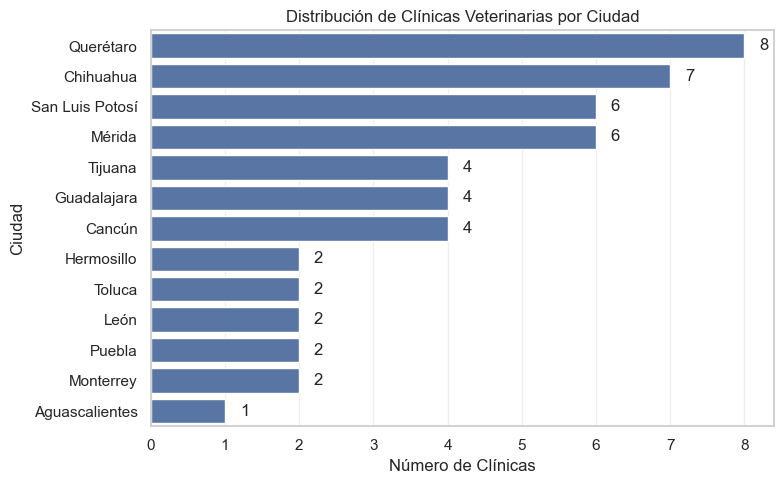

In [4]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    y="city",
    data=clinics_df,
    order=clinics_df["city"].value_counts().index
)

plt.title("Distribución de Clínicas Veterinarias por Ciudad")

plt.xlabel("Número de Clínicas")
plt.ylabel("Ciudad")

# adicionar valores nas barras
for p in ax.patches:
    ax.text(
        p.get_width() + 0.2,
        p.get_y() + p.get_height()/2,
        int(p.get_width()),
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

save_plot("clinics_by_city")

plt.tight_layout()

plt.show()

La distribución de clínicas revela cómo se organiza la red
veterinaria en las distintas ciudades.

Algunas ciudades concentran un mayor número de clínicas,
lo que puede reflejar una mayor demanda potencial o una
mayor densidad de población.

Estas diferencias geográficas ayudan a contextualizar
los patrones de actividad observados en las clínicas.

## Distribución de servicios veterinarios

Las clínicas ofrecen diferentes tipos de servicios que
incluyen consultas generales, vacunaciones y procedimientos
más especializados.

Analizar la distribución de estos servicios permite
identificar qué tipos de atención generan la mayor
parte de las visitas en la red.

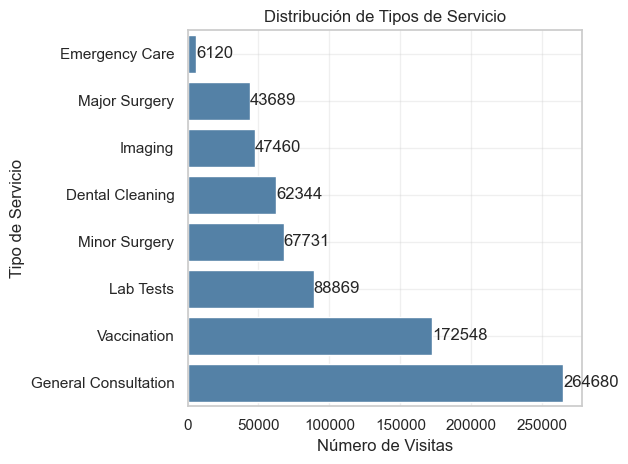

In [5]:
plt.figure()

service_counts = visits_df["service_type"].value_counts().sort_values()

ax = sns.barplot(
    x=service_counts.values,
    y=service_counts.index,
    color="steelblue"
)

for i, v in enumerate(service_counts.values):
    ax.text(v + 50, i, str(v), va="center")

plt.title("Distribución de Tipos de Servicio")
plt.xlabel("Número de Visitas")
plt.ylabel("Tipo de Servicio")

plt.grid(alpha=0.3)

save_plot("service_type_distribution")

plt.tight_layout()
plt.show()

La distribución de servicios muestra que algunos tipos de
atención concentran una proporción considerable del total
de visitas.

Servicios rutinarios como consultas o vacunaciones suelen
representar una gran parte de la actividad clínica,
mientras que procedimientos más especializados ocurren
con menor frecuencia.

Este patrón es típico en sistemas de salud y tiene
implicaciones directas para la planificación de recursos
y la organización de la atención.

## Evolución de la demanda en la red

Comprender cómo evoluciona la demanda a lo largo del tiempo
es fundamental para la planificación operativa.

Los patrones temporales pueden revelar fluctuaciones,
tendencias y posibles comportamientos estacionales que
influyen en la gestión de las clínicas.

El siguiente gráfico muestra la evolución del número total
de visitas en toda la red veterinaria.

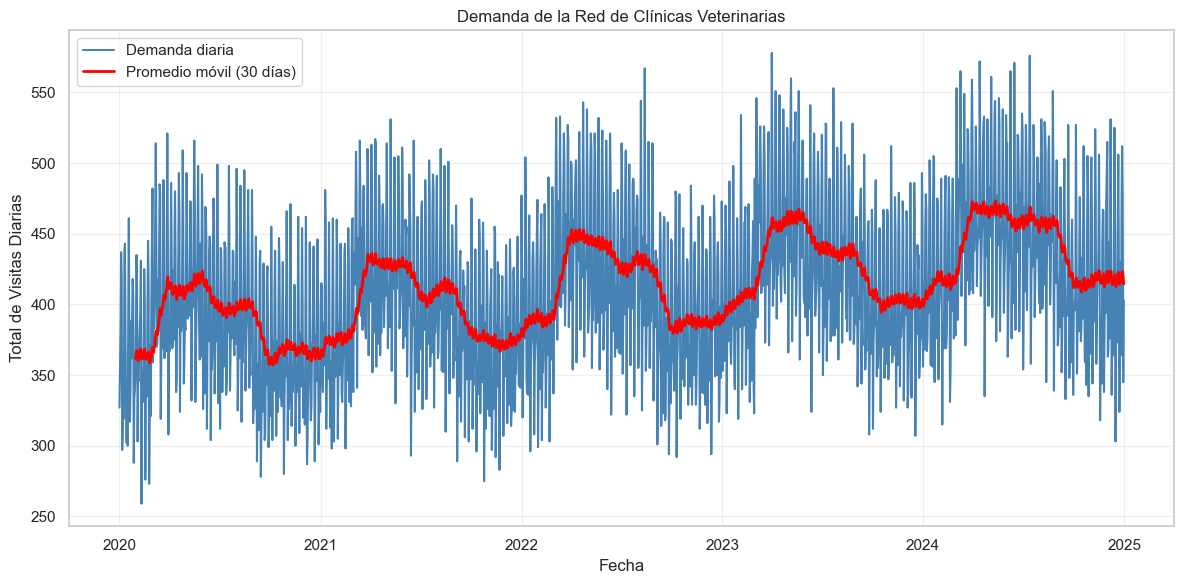

In [6]:
network_demand = (
    forecast_df
    .groupby("visit_date")["daily_visits"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=network_demand,
    x="visit_date",
    y="daily_visits",
    color="steelblue",
    label="Demanda diaria"
)

# média móvel para mostrar tendência
rolling_mean = network_demand["daily_visits"].rolling(30).mean()

plt.plot(
    network_demand["visit_date"],
    rolling_mean,
    color="red",
    linewidth=2,
    label="Promedio móvil (30 días)"
)

plt.title("Demanda de la Red de Clínicas Veterinarias")

plt.xlabel("Fecha")
plt.ylabel("Total de Visitas Diarias")

plt.legend()

plt.grid(alpha=0.3)

save_plot("network_daily_demand")

plt.tight_layout()

plt.show()

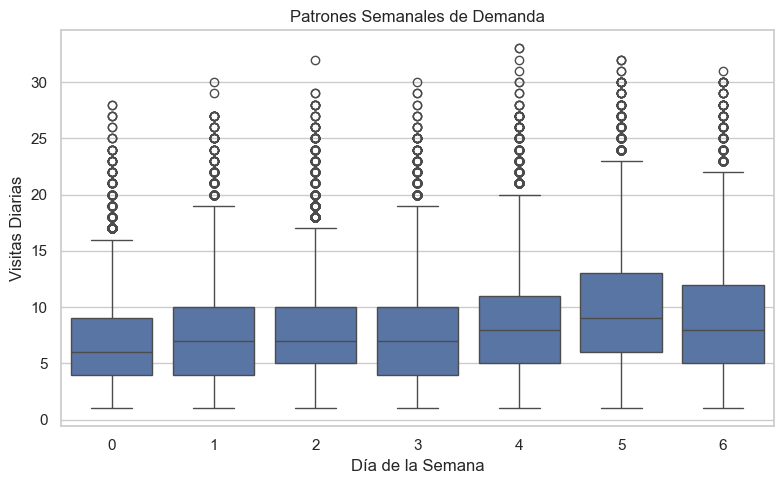

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="day_of_week",
    y="daily_visits",
    data=forecast_df
)

plt.title("Patrones Semanales de Demanda")

plt.xlabel("Día de la Semana")
plt.ylabel("Visitas Diarias")

save_plot("weekly_demand_patterns")

plt.tight_layout()

plt.show()

La serie temporal de visitas muestra una variabilidad
significativa en la demanda de servicios veterinarios.

Estas fluctuaciones pueden estar relacionadas con factores
operativos, comportamientos de los propietarios de mascotas
o patrones de citas.

Este comportamiento dinámico resalta la importancia de
desarrollar modelos capaces de anticipar la demanda futura.

## Distribución de ingresos entre clínicas

Las clínicas dentro de la red no operan todas al mismo
nivel de actividad.

Factores como la ubicación, el volumen de pacientes y
el tipo de servicios ofrecidos pueden generar diferencias
importantes en los ingresos entre clínicas.

Analizar esta distribución permite entender mejor la
heterogeneidad operativa dentro de la red.

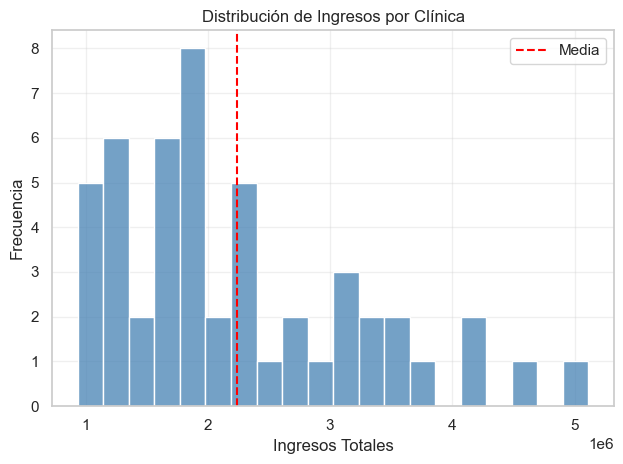

In [8]:
clinic_revenue = (
    visits_df
    .groupby("clinic_id")["total_visit_cost"]
    .sum()
)

plt.figure()

sns.histplot(
    clinic_revenue,
    bins=20,
    color="steelblue"
)

plt.axvline(
    clinic_revenue.mean(),
    color="red",
    linestyle="--",
    label="Media"
)

plt.title("Distribución de Ingresos por Clínica")
plt.xlabel("Ingresos Totales")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(alpha=0.3)

save_plot("clinic_revenue_distribution")

plt.tight_layout()
plt.show()

## Distribución de ingresos entre clínicas

Las clínicas presentan diferentes niveles de ingresos,
reflejando variaciones en:

• volumen de pacientes  
• mix de servicios  
• características de la ubicación

Este análisis permite identificar clínicas con perfiles
operativos distintos dentro de la red.

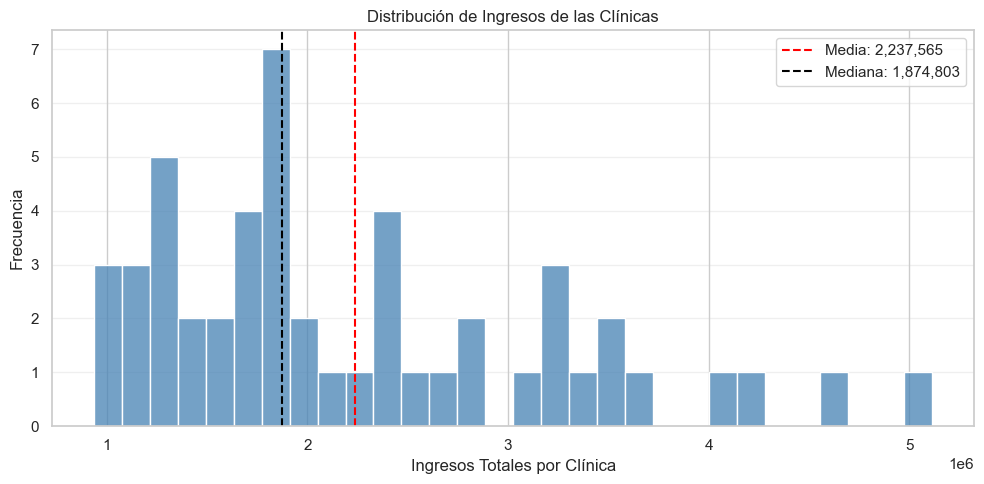

In [9]:
clinic_revenue = (
    visits_df
    .groupby("clinic_id")["total_visit_cost"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.histplot(
    clinic_revenue["total_visit_cost"],
    bins=30,
    color="steelblue"
)

mean_rev = clinic_revenue["total_visit_cost"].mean()
median_rev = clinic_revenue["total_visit_cost"].median()

plt.axvline(
    mean_rev,
    linestyle="--",
    color="red",
    label=f"Media: {mean_rev:,.0f}"
)

plt.axvline(
    median_rev,
    linestyle="--",
    color="black",
    label=f"Mediana: {median_rev:,.0f}"
)

plt.title("Distribución de Ingresos de las Clínicas")

plt.xlabel("Ingresos Totales por Clínica")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("clinic_revenue_distribution")

plt.tight_layout()

plt.show()

### Interpretación de la distribución de servicios

La distribución de servicios veterinarios revela patrones claros en la
demanda dentro de la red de clínicas.

Las **consultas generales** representan el mayor volumen de visitas,
lo cual es esperado en sistemas de atención veterinaria, ya que este
tipo de servicio suele ser el primer punto de contacto para la mayoría
de los pacientes.

Los **servicios preventivos**, como la vacunación, también muestran
una demanda significativa, reflejando la importancia del cuidado
preventivo en la salud animal.

Por otro lado, procedimientos más especializados como **cirugías
mayores** o **servicios de emergencia** presentan un volumen menor
de visitas, lo cual es consistente con su naturaleza menos frecuente
pero más compleja.

Este patrón de demanda tiene implicaciones importantes para la
planificación operativa de las clínicas, especialmente en la
asignación de recursos, la planificación del personal veterinario
y la organización de las agendas de atención.

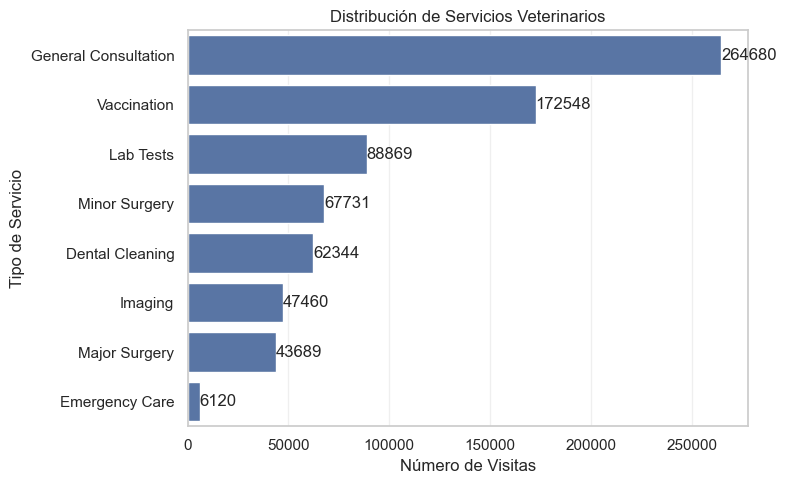

In [10]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    y="service_type",
    data=visits_df,
    order=visits_df["service_type"].value_counts().index
)

plt.title("Distribución de Servicios Veterinarios")

plt.xlabel("Número de Visitas")
plt.ylabel("Tipo de Servicio")

# adicionar valores nas barras
for p in ax.patches:
    ax.text(
        p.get_width() + 0.5,
        p.get_y() + p.get_height()/2,
        int(p.get_width()),
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

save_plot("service_type_distribution")

plt.tight_layout()

plt.show()

### Interpretación de la serie temporal de demanda

La serie temporal muestra la evolución del número de visitas
diarias registradas en la red de clínicas veterinarias.

La línea azul representa la **demanda diaria observada**, que
presenta una variabilidad considerable a lo largo del tiempo.
Estas fluctuaciones reflejan el comportamiento natural de la
demanda en servicios veterinarios, donde factores como la
programación de citas, emergencias médicas o el comportamiento
de los propietarios de mascotas pueden influir en el número
de visitas diarias.

La línea roja corresponde a un **promedio móvil de 14 días**,
que permite suavizar las fluctuaciones diarias y visualizar
mejor la tendencia general de la demanda.

Este tipo de análisis temporal es fundamental para identificar
patrones de comportamiento en la demanda y constituye la base
para el desarrollo de modelos de predicción que permitan
anticipar el volumen futuro de visitas en las clínicas.

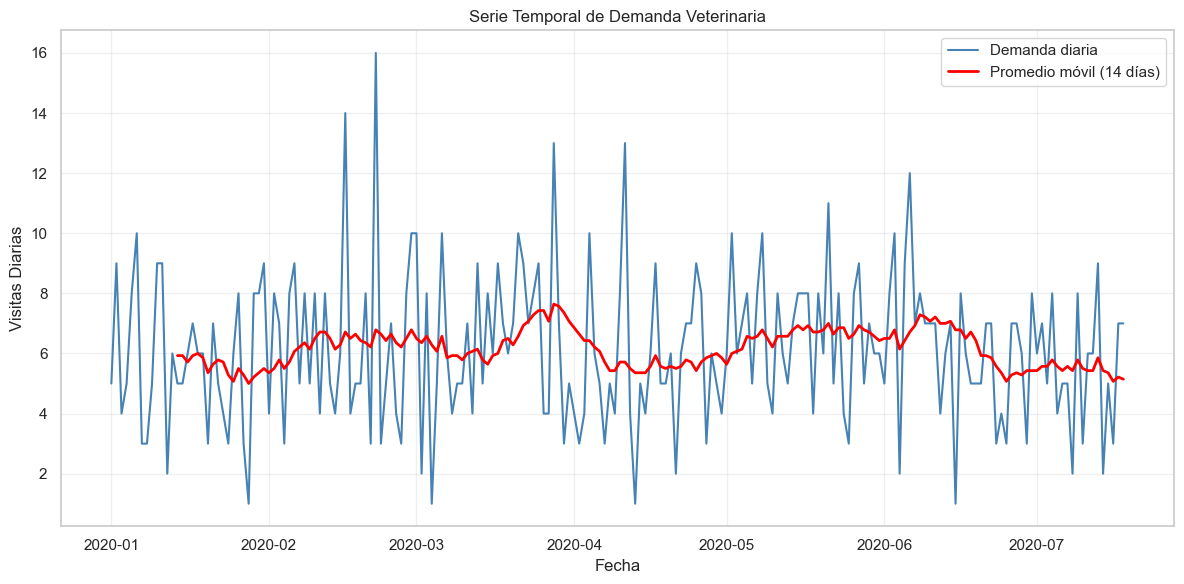

In [11]:
plt.figure(figsize=(12,6))

sample = forecast_df.iloc[:200]

sns.lineplot(
    x=sample["visit_date"],
    y=sample["daily_visits"],
    label="Demanda diaria",
    color="steelblue"
)

# média móvel para mostrar tendência
rolling_mean = sample["daily_visits"].rolling(14).mean()

plt.plot(
    sample["visit_date"],
    rolling_mean,
    color="red",
    linewidth=2,
    label="Promedio móvil (14 días)"
)

plt.title("Serie Temporal de Demanda Veterinaria")

plt.xlabel("Fecha")
plt.ylabel("Visitas Diarias")

plt.legend()

plt.grid(alpha=0.3)

save_plot("demand_timeseries_example")

plt.tight_layout()

plt.show()

## Principales Insights

El análisis revela varios patrones importantes en las operaciones de las clínicas veterinarias.

• La demanda veterinaria sigue fuertes ciclos semanales.

• Los niveles recientes de demanda influyen significativamente en la demanda futura.

• El desempeño de las clínicas varía considerablemente entre diferentes ubicaciones.

• Algunas clínicas operan cerca de su capacidad mientras que otras permanecen subutilizadas.

• La demanda de emergencias introduce una variabilidad operativa adicional.

## Recomendaciones Estratégicas

Con base en el análisis, surgen varias oportunidades para mejorar la eficiencia operativa.

**Optimizar la Asignación de Personal**

Los modelos de pronóstico pueden ayudar a anticipar picos de demanda y ajustar los niveles de personal.

**Expandir la Capacidad en Clínicas con Alta Demanda**

Las clínicas que operan cerca de su capacidad pueden beneficiarse de más veterinarios o de la expansión de sus instalaciones.

**Incrementar la Demanda en Clínicas Subutilizadas**

Iniciativas de marketing o la diversificación de servicios podrían aumentar la utilización de las clínicas.

**Mejorar la Planificación de Respuesta ante Emergencias**

Las clínicas con mayor demanda de emergencias pueden requerir modelos de personal más flexibles.